<a href="https://colab.research.google.com/github/Keerthanapalvannan-25/Customer-Churn-Prediction/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Loading**

In [1]:
import pandas as pd
df = pd.read_csv('Churn_Modelling.csv')
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

print("✅ Step 1 Completed: Data Loaded Successfully!")
print(f"Total Customers: {len(df)}")
print("\nFirst 5 rows of the processed data:")
print(df.head())

✅ Step 1 Completed: Data Loaded Successfully!
Total Customers: 10000

First 5 rows of the processed data:
   CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619    France  Female   42       2       0.00              1   
1          608     Spain  Female   41       1   83807.86              1   
2          502    France  Female   42       8  159660.80              3   
3          699    France  Female   39       1       0.00              2   
4          850     Spain  Female   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  
0          1               1        101348.88       1  
1          0               1        112542.58       0  
2          1               0        113931.57       1  
3          0               0         93826.63       0  
4          1               1         79084.10       0  


# **Data Preprocessing**

In [2]:
from sklearn.preprocessing import LabelEncoder

# 1. Encode 'Gender' (Binary: 0 or 1)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# 2. Encode 'Geography' (One-Hot Encoding for France, Spain, Germany)
# This creates separate columns for each country
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

# 3. Define Features (X) and Target (y)
# 'Exited' is our target (1 = Left the bank, 0 = Stayed)
X = df.drop('Exited', axis=1)
y = df['Exited']

# 4. Split into Training and Testing sets (80% Train, 20% Test)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Feature Scaling
# Scaling ensures that 'Balance' (large numbers) doesn't overpower 'Age' (small numbers)
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

print("✅ Step 2 Completed!")
print(f"Number of training samples: {X_train.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")

✅ Step 2 Completed!
Number of training samples: 8000
Number of features: 11


# **Model Traning & Evaluation**

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# 1. Initialize the Random Forest Model
# n_estimators=100 means we are using 100 individual decision trees to vote
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the model on your training data
print("Training the Random Forest model... please wait.")
rf_model.fit(X_train, y_train)

# 3. Predict the churn for the test set
y_pred = rf_model.predict(X_test)

# 4. Evaluate the results
print("✅ Step 3 Completed!")
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

Training the Random Forest model... please wait.
✅ Step 3 Completed!
Model Accuracy: 86.65%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.76      0.46      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



# **Feature importance & Visualization**

/tmp/ipykernel_323/2638545881.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


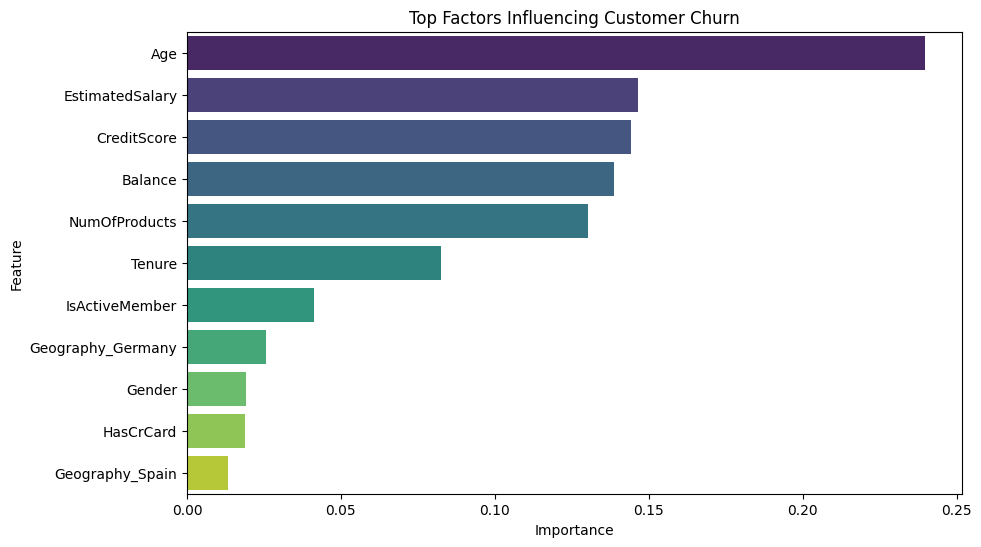

✅ Step 4 Completed!


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Function to predict churn for a new customer
def predict_churn(customer_data):
    # Scale the input data just like we did for the training set
    scaled_data = sc.transform(customer_data)
    prediction = rf_model.predict(scaled_data)
    return "Customer will LEAVE" if prediction[0] == 1 else "Customer will STAY"

# 2. Visualize Feature Importance
# This shows which factors (Age, Balance, etc.) influence churn the most
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Top Factors Influencing Customer Churn')
plt.show()

print("✅ Step 4 Completed!")

# **Saving the Model**

In [5]:
import pickle

# 1. Save the Random Forest Model
with open('bank_churn_model.pkl', 'wb') as model_file:
    pickle.dump(rf_model, model_file)

# 2. Save the Scaler (StandardScaler)
# You MUST save this to process new customer data the same way
with open('churn_scaler.pkl', 'wb') as scaler_file:
    pickle.dump(sc, scaler_file)

print("✅ Model and Scaler saved as 'bank_churn_model.pkl' and 'churn_scaler.pkl'")

✅ Model and Scaler saved as 'bank_churn_model.pkl' and 'churn_scaler.pkl'
